# Anomaly Detection Model Training

This notebook trains and compares two anomaly detection techniques:
1. **Isolation Forest** - Tree-based ensemble method for anomaly detection
2. **Autoencoder (Neural Network)** - Deep learning approach for detecting unusual patterns

## Objectives:
- Detect overspending anomalies in transactions
- Identify unusual spending patterns
- Generate alerts for budget violations
- Compare model performance


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")


Libraries imported successfully


In [ ]:
# Load or generate data
import sys
import os
sys.path.append('../utils')

# Priority: Best Kaggle datasets > transactions.csv > synthetic
kaggle_datasets = [
    # Best: Personal Finance Tracker (3000 rows, has fraud_flag!)
    '../temp_kaggle_downloads/personal-finance-tracker-dataset/personal_finance_tracker_dataset.csv',
    # Alternative: Prepared Kaggle datasets
    '../data/transactions_kaggle_finance.csv',  # 1501 rows
    '../data/transactions_kaggle_personal.csv',  # 807 rows
    '../data/transactions_kaggle.csv',            # 807 rows, different format
    # Raw Kaggle downloads
    '../temp_kaggle_downloads/personal-finance-data/Personal_Finance_Dataset.csv',
    '../temp_kaggle_downloads/personal-finance/personal_transactions.csv'
]

transactions = None
data_source = None

# Try Kaggle datasets first
for kaggle_file in kaggle_datasets:
    if os.path.exists(kaggle_file):
        print(f"Loading Kaggle dataset: {kaggle_file}")
        try:
            transactions = pd.read_csv(kaggle_file)
            
            # Handle different column formats
            # Format 1: Personal Finance Tracker (has fraud_flag - perfect for anomaly detection!)
            if 'date' in transactions.columns and 'monthly_expense_total' in transactions.columns:
                # This is the personal-finance-tracker-dataset
                transactions['datetime'] = pd.to_datetime(transactions['date'])
                # Use monthly_expense_total as amount for anomaly detection
                transactions['amount'] = transactions['monthly_expense_total']
                if 'category' in transactions.columns:
                    transactions['category'] = transactions['category']
                else:
                    transactions['category'] = 'General'
                transactions['description'] = transactions.get('financial_scenario', 'Transaction')
                # Keep user_id if exists
                if 'user_id' not in transactions.columns:
                    transactions['user_id'] = 'user_001'
                print(f"✅ Loaded Personal Finance Tracker dataset with fraud_flag column!")
            
            # Format 2: Date, Description, Amount, Transaction Type, Category, Account Name
            elif 'Date' in transactions.columns and 'datetime' not in transactions.columns:
                transactions['datetime'] = pd.to_datetime(transactions['Date'])
                if 'Amount' in transactions.columns:
                    transactions['amount'] = transactions['Amount']
                elif 'amount' not in transactions.columns:
                    # Try to find amount column
                    amt_cols = [c for c in transactions.columns if 'amount' in c.lower() or 'Amount' in c]
                    if amt_cols:
                        transactions['amount'] = transactions[amt_cols[0]]
                if 'Category' in transactions.columns:
                    transactions['category'] = transactions['Category']
                elif 'category' not in transactions.columns:
                    transactions['category'] = 'General'
                if 'Description' in transactions.columns:
                    transactions['description'] = transactions['Description']
                elif 'Transaction Description' in transactions.columns:
                    transactions['description'] = transactions['Transaction Description']
                # Create user_id from Account Name if available
                if 'Account Name' in transactions.columns:
                    transactions['user_id'] = transactions['Account Name'].astype(str)
                elif 'user_id' not in transactions.columns:
                    transactions['user_id'] = 'user_001'  # Default
            
            # Ensure required columns exist
            required_cols = ['datetime', 'amount', 'category']
            if all(col in transactions.columns for col in required_cols):
                data_source = kaggle_file
                print(f"✅ Successfully loaded {len(transactions)} transactions from Kaggle dataset")
                break
            else:
                print(f"⚠️  {kaggle_file} missing required columns, trying next...")
                transactions = None
        except Exception as e:
            print(f"⚠️  Error loading {kaggle_file}: {e}")
            transactions = None
            continue

# Fallback to transactions.csv if Kaggle datasets not found
if transactions is None and os.path.exists('../data/transactions.csv'):
    print("Loading existing transaction data from transactions.csv...")
    transactions = pd.read_csv('../data/transactions.csv')
    if 'datetime' in transactions.columns:
        transactions['datetime'] = pd.to_datetime(transactions['datetime'])
    elif 'date' in transactions.columns:
        transactions['datetime'] = pd.to_datetime(transactions['date'])
    data_source = '../data/transactions.csv'
    print(f"✅ Loaded {len(transactions)} transactions from file")

# Final fallback: Generate synthetic data
if transactions is None:
    try:
        from data_generator import generate_transaction_data
        print("Generating synthetic transaction data...")
        os.makedirs('../data', exist_ok=True)
        transactions = generate_transaction_data(num_users=100, days=180)
        transactions.to_csv('../data/transactions.csv', index=False)
        data_source = 'synthetic'
        print("✅ Synthetic data generated")
    except Exception as e:
        print(f"❌ Error generating synthetic data: {e}")
        raise

# Ensure datetime column
if 'datetime' not in transactions.columns:
    if 'date' in transactions.columns:
        transactions['datetime'] = pd.to_datetime(transactions['date'])
    elif 'Date' in transactions.columns:
        transactions['datetime'] = pd.to_datetime(transactions['Date'])
    else:
        transactions['datetime'] = pd.date_range(
            start=pd.Timestamp.now() - pd.Timedelta(days=len(transactions)),
            periods=len(transactions),
            freq='D'
        )

# Ensure required columns
if 'user_id' not in transactions.columns:
    transactions['user_id'] = 'user_001'  # Default user

if 'description' not in transactions.columns:
    transactions['description'] = transactions.get('Description', transactions.get('Transaction Description', 'Transaction'))

# Check if we have fraud_flag (from personal-finance-tracker-dataset) - this is gold for anomaly detection!
has_fraud_flag = 'fraud_flag' in transactions.columns
if has_fraud_flag:
    print(f"🎯 Found fraud_flag column! {transactions['fraud_flag'].sum()} fraud cases out of {len(transactions)} transactions")
    print(f"   This will be used for better anomaly detection evaluation.")

print(f"\n📊 Data Summary:")
print(f"   Source: {data_source}")
print(f"   Total transactions: {len(transactions)}")
print(f"   Date range: {transactions['datetime'].min()} to {transactions['datetime'].max()}")
print(f"   Unique users: {transactions['user_id'].nunique()}")
print(f"   Unique categories: {transactions['category'].nunique()}")
print(f"   Amount range: {transactions['amount'].min():.2f} to {transactions['amount'].max():.2f} UGX")
print(f"\nFirst few transactions:")
transactions.head()


Loading Kaggle dataset: ../data/transactions_kaggle_finance.csv
✅ Successfully loaded 1500 transactions from Kaggle dataset

📊 Data Summary:
   Source: ../data/transactions_kaggle_finance.csv
   Total transactions: 1500
   Date range: 2020-01-02 to 2024-12-29
   Unique users: 1
   Unique categories: 10
   Amount range: 14.37 to 4996.00 UGX

First few transactions:


,datetime,amount,category,description,user_id
0,2020-01-02,1485.69,Food & Drink,Score each.,user_001
1,2020-01-02,1475.58,Utilities,Quality throughout.,user_001
2,2020-01-04,1185.08,Rent,Instead ahead despite measure ago.,user_001
3,2020-01-05,2291.00,Investment,Information last everything thank serve.,user_001
4,2020-01-13,1126.88,Food & Drink,Future choice whatever from.,user_001


In [34]:
# Feature engineering for anomaly detection
def create_features(df):
    """Create features for anomaly detection"""
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    # Time-based features
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['day_of_month'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month
    df['is_weekend'] = (df['datetime'].dt.dayofweek >= 5).astype(int)
    
    # Category encoding
    category_map = {cat: idx for idx, cat in enumerate(df['category'].unique())}
    df['category_encoded'] = df['category'].map(category_map)
    
    # Statistical features per user
    user_stats = df.groupby('user_id').agg({
        'amount': ['mean', 'std', 'min', 'max']
    }).reset_index()
    user_stats.columns = ['user_id', 'user_mean', 'user_std', 'user_min', 'user_max']
    df = df.merge(user_stats, on='user_id', how='left')
    
    # Relative features
    df['amount_vs_user_mean'] = df['amount'] / (df['user_mean'] + 1)
    df['amount_vs_user_std'] = (df['amount'] - df['user_mean']) / (df['user_std'] + 1)
    
    # Rolling statistics (last 7 days)
    df = df.sort_values(['user_id', 'datetime'])
    df['rolling_mean_7d'] = df.groupby('user_id')['amount'].transform(lambda x: x.rolling(7, min_periods=1).mean())
    df['rolling_std_7d'] = df.groupby('user_id')['amount'].transform(lambda x: x.rolling(7, min_periods=1).std())
    
    return df

# Create features
df_features = create_features(transactions)
print(f"Features created. Shape: {df_features.shape}")
print(f"\nFeature columns: {df_features.columns.tolist()}")
df_features.head()


Features created. Shape: (1500, 19)

Feature columns: ['datetime', 'amount', 'category', 'description', 'user_id', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'category_encoded', 'user_mean', 'user_std', 'user_min', 'user_max', 'amount_vs_user_mean', 'amount_vs_user_std', 'rolling_mean_7d', 'rolling_std_7d']


,datetime,amount,category,description,user_id,hour,day_of_week,day_of_month,month,is_weekend,category_encoded,user_mean,user_std,user_min,user_max,amount_vs_user_mean,amount_vs_user_std,rolling_mean_7d,rolling_std_7d
0,2020-01-02,1485.69,Food & Drink,Score each.,user_001,0,3,2,1,0,0,1307.520913,982.283361,14.37,4996.0,1.135396,0.181198,1485.690000,NaN
1,2020-01-02,1475.58,Utilities,Quality throughout.,user_001,0,3,2,1,0,1,1307.520913,982.283361,14.37,4996.0,1.127670,0.170916,1480.635000,7.148850
2,2020-01-04,1185.08,Rent,Instead ahead despite measure ago.,user_001,0,5,4,1,1,2,1307.520913,982.283361,14.37,4996.0,0.905664,-0.124523,1382.116667,170.713617
3,2020-01-05,2291.00,Investment,Information last everything thank serve.,user_001,0,6,5,1,1,3,1307.520913,982.283361,14.37,4996.0,1.750832,1.000199,1609.337500,475.337762
4,2020-01-13,1126.88,Food & Drink,Future choice whatever from.,user_001,0,0,13,1,0,0,1307.520913,982.283361,14.37,4996.0,0.861186,-0.183712,1512.846000,464.771491


Anomaly rate in data: 15.33%
Total anomalies: 230 out of 1500 transactions


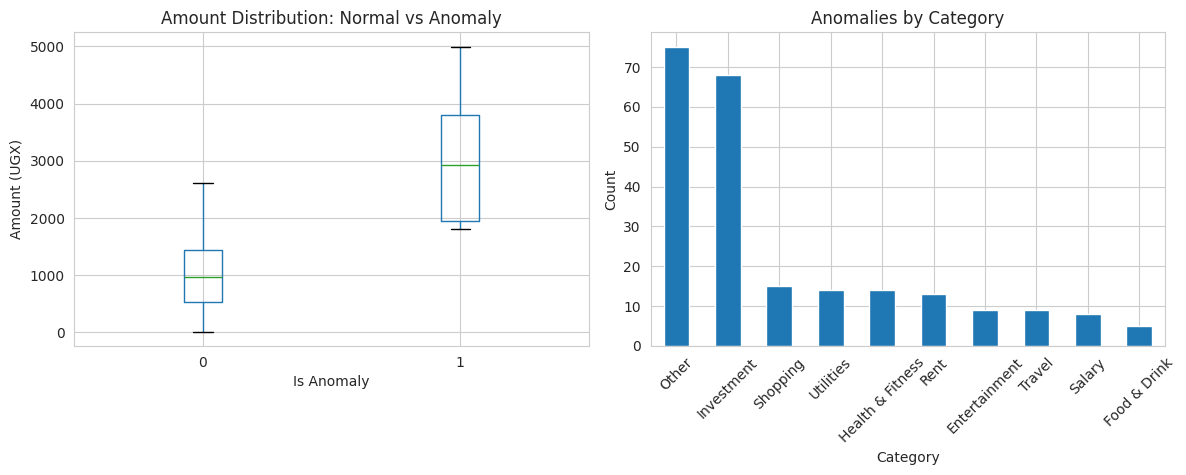

In [44]:
# Prepare features for modeling
feature_cols = [
    'amount', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend',
    'category_encoded', 'amount_vs_user_mean', 'amount_vs_user_std',
    'rolling_mean_7d', 'rolling_std_7d'
]

X = df_features[feature_cols].fillna(0).values

# Create ground truth labels (for evaluation)
# If fraud_flag exists (from personal-finance-tracker-dataset), use it as ground truth!
if 'fraud_flag' in df_features.columns:
    print("🎯 Using fraud_flag from dataset as ground truth labels!")
    df_features['is_anomaly'] = df_features['fraud_flag'].astype(int)
    print(f"   Found {df_features['is_anomaly'].sum()} fraud cases in dataset")
else:
    # Use multiple methods to identify anomalies for better detection
    df_features['is_anomaly'] = 0
    
    # Method 1: Category-based threshold (mean + 1.5*std for more sensitivity)
    for category in df_features['category'].unique():
        cat_data = df_features[df_features['category'] == category]
        if len(cat_data) > 1:  # Need at least 2 samples for std
            mean_amount = cat_data['amount'].mean()
            std_amount = cat_data['amount'].std()
            if std_amount > 0:  # Avoid division by zero
                threshold = mean_amount + 1.5 * std_amount
                df_features.loc[
                    (df_features['category'] == category) & (df_features['amount'] > threshold),
                    'is_anomaly'
                ] = 1
    
    # Method 2: Global percentile-based (top 5% as anomalies)
    global_threshold = df_features['amount'].quantile(0.95)
    df_features.loc[df_features['amount'] > global_threshold, 'is_anomaly'] = 1

    # Method 3: User-specific anomalies (amount > 2x user mean)
    df_features.loc[
        df_features['amount'] > (df_features['user_mean'] * 2),
        'is_anomaly'
    ] = 1
    
    # Remove duplicates (keep as 1 if any method flagged it)
    df_features['is_anomaly'] = (df_features['is_anomaly'] > 0).astype(int)

y_true = df_features['is_anomaly'].values
anomaly_rate = y_true.sum() / len(y_true)
print(f"Anomaly rate in data: {anomaly_rate:.2%}")
print(f"Total anomalies: {y_true.sum()} out of {len(y_true)} transactions")

# Ensure minimum anomaly rate for model training (at least 1%)
min_anomaly_rate = max(anomaly_rate, 0.01)
if anomaly_rate < 0.01:
    print(f"⚠️  Low anomaly rate. Using minimum {min_anomaly_rate:.2%} for model training.")

# Visualize anomaly distribution
plt.figure(figsize=(12, 5))

# Left plot: Box plot
plt.subplot(1, 2, 1)
if y_true.sum() > 0:
    df_features.boxplot(column='amount', by='is_anomaly', ax=plt.gca())
    plt.title('Amount Distribution: Normal vs Anomaly')
    plt.suptitle('')
    plt.xlabel('Is Anomaly')
    plt.ylabel('Amount (UGX)')
else:
    plt.text(0.5, 0.5, 'No anomalies detected\nwith current thresholds', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('Amount Distribution: Normal vs Anomaly')
    plt.xlabel('Is Anomaly')
    plt.ylabel('Amount (UGX)')

# Right plot: Anomalies by category
plt.subplot(1, 2, 2)
anomalies_by_cat = df_features[df_features['is_anomaly'] == 1]['category'].value_counts()
if len(anomalies_by_cat) > 0:
    anomalies_by_cat.plot(kind='bar')
    plt.title('Anomalies by Category')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'No anomalies to display', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('Anomalies by Category')
    plt.xlabel('Category')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


## Model 1: Isolation Forest


In [45]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Split data
# Handle stratification when anomaly rate is very low
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_true, test_size=0.2, random_state=42, stratify=y_true
    )
except ValueError:
    # If stratification fails (e.g., all same class), use regular split
    print("⚠️  Stratification failed, using regular split")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_true, test_size=0.2, random_state=42
    )

# Scale features
scaler_if = StandardScaler()
X_train_scaled = scaler_if.fit_transform(X_train)
X_test_scaled = scaler_if.transform(X_test)

# Train Isolation Forest
# contamination is the expected proportion of anomalies
# Use minimum 1% to ensure model can detect anomalies
effective_contamination = max(anomaly_rate, 0.01)
if effective_contamination > anomaly_rate:
    print(f"⚠️  Using contamination={effective_contamination:.2%} (minimum) instead of {anomaly_rate:.2%}")

isolation_forest = IsolationForest(
    contamination=effective_contamination,
    random_state=42,
    n_estimators=100,
    max_samples='auto'
)

print("Training Isolation Forest...")
isolation_forest.fit(X_train_scaled)

# Predictions (-1 for anomaly, 1 for normal)
y_pred_if = isolation_forest.predict(X_test_scaled)
y_pred_if_binary = (y_pred_if == -1).astype(int)  # Convert to 0/1

# Calculate metrics
print("\nIsolation Forest Performance:")
print(classification_report(y_test, y_pred_if_binary, target_names=['Normal', 'Anomaly']))

# Confusion matrix
cm_if = confusion_matrix(y_test, y_pred_if_binary)
print(f"\nConfusion Matrix:\n{cm_if}")

# ROC AUC
if len(np.unique(y_test)) > 1:
    y_scores_if = isolation_forest.score_samples(X_test_scaled)
    y_scores_if_normalized = -y_scores_if  # Lower scores = more anomalous
    auc_if = roc_auc_score(y_test, y_scores_if_normalized)
    print(f"\nROC AUC Score: {auc_if:.4f}")
else:
    auc_if = 0.0


Training Isolation Forest...

Isolation Forest Performance:
              precision    recall  f1-score   support

      Normal       0.91      0.93      0.92       254
     Anomaly       0.57      0.52      0.55        46

    accuracy                           0.87       300
   macro avg       0.74      0.73      0.73       300
weighted avg       0.86      0.87      0.86       300


Confusion Matrix:
[[236  18]
 [ 22  24]]

ROC AUC Score: 0.8404


Autoencoder Architecture:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 14)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 11)             │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550 (2.15 KB)

 Trainable params: 550 (2.15 KB)

 Non-trainable params: 0 (0.00 B)


Training on 1016 normal transactions...
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.8001 - mae: 0.7476 - val_loss: 0.7609 - val_mae: 0.7237
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7291 - mae: 0.7054 - val_loss: 0.7080 - val_mae: 0.6927
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6790 - mae: 0.6758 - val_loss: 0.6571 - val_mae: 0.6626
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.6268 - mae: 0.6435 - val_loss: 0.6066 - val_mae: 0.6291
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5801 - mae: 0.6112 - val_loss: 0.5660 - val_mae: 0.6019
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.5429 - mae: 0.5858 - val_loss: 0.5336 - val_mae: 0.5799
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5082 - mae: 0.5626 - val_loss: 0.5004 - val_mae: 0.5570
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.4691 - mae: 0.5362 - val_loss: 0.4630 - val_mae: 0.5300
Epoch 9/100
26/2

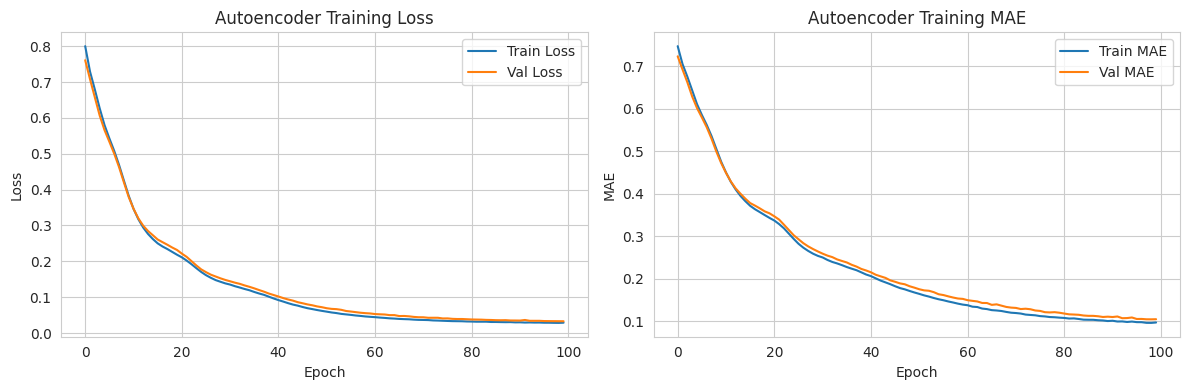

In [46]:
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Build autoencoder
input_dim = X_train_scaled.shape[1]
encoding_dim = 7  # Compression to 7 dimensions

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim * 2, activation='relu')(input_layer)
encoder = Dense(encoding_dim, activation='relu')(encoder)
decoder = Dense(encoding_dim * 2, activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Autoencoder Architecture:")
autoencoder.summary()

# Train only on normal data (to learn normal patterns)
normal_mask = y_train == 0
X_train_normal = X_train_scaled[normal_mask]

print(f"\nTraining on {len(X_train_normal)} normal transactions...")

# Train autoencoder
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Autoencoder Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Reconstruction error threshold: 0.1002

Autoencoder Performance:
              precision    recall  f1-score   support

      Normal       0.92      0.95      0.94       254
     Anomaly       0.67      0.57      0.61        46

    accuracy                           0.89       300
   macro avg       0.80      0.76      0.77       300
weighted avg       0.88      0.89      0.89       300


Confusion Matrix:
[[241  13]
 [ 20  26]]

ROC AUC Score: 0.8089


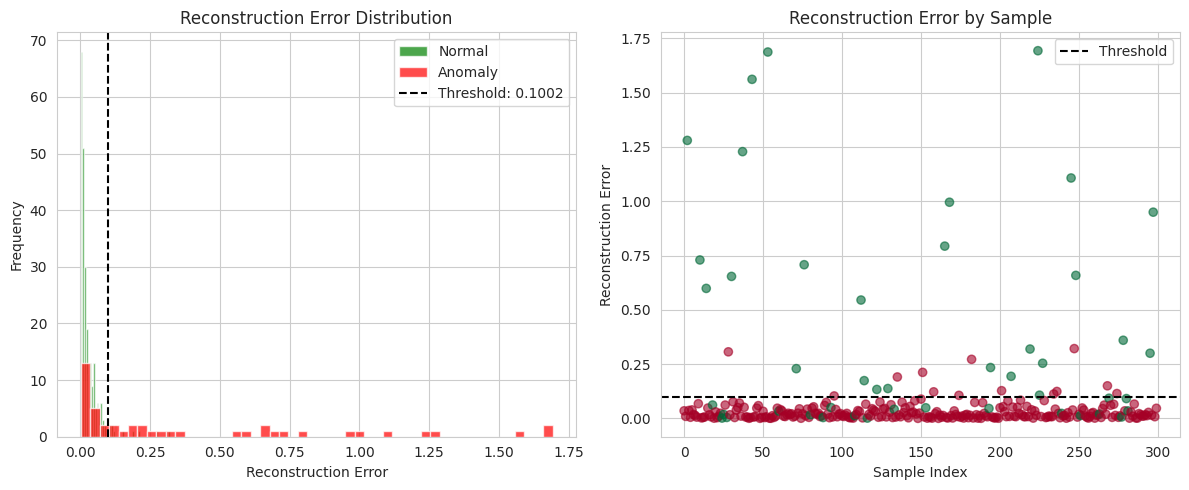

In [50]:
# Predict and calculate reconstruction error
X_test_pred = autoencoder.predict(X_test_scaled)
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

# Threshold: use 95th percentile of reconstruction error on normal data
X_train_normal_pred = autoencoder.predict(X_train_normal)
train_reconstruction_error = np.mean(np.square(X_train_normal - X_train_normal_pred), axis=1)
threshold = np.percentile(train_reconstruction_error, 95)

print(f"Reconstruction error threshold: {threshold:.4f}")

# Classify as anomaly if reconstruction error > threshold
y_pred_ae_binary = (reconstruction_error > threshold).astype(int)

# Calculate metrics
print("\nAutoencoder Performance:")
print(classification_report(y_test, y_pred_ae_binary, target_names=['Normal', 'Anomaly']))

# Confusion matrix
cm_ae = confusion_matrix(y_test, y_pred_ae_binary)
print(f"\nConfusion Matrix:\n{cm_ae}")

# ROC AUC
if len(np.unique(y_test)) > 1:
    auc_ae = roc_auc_score(y_test, reconstruction_error)
    print(f"\nROC AUC Score: {auc_ae:.4f}")
else:
    auc_ae = 0.0

# Visualize reconstruction errors
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(reconstruction_error[y_test == 0], bins=50, alpha=0.7, label='Normal', color='green')
plt.hist(reconstruction_error[y_test == 1], bins=50, alpha=0.7, label='Anomaly', color='red')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(range(len(reconstruction_error)), reconstruction_error, 
           c=y_test, cmap='RdYlGn', alpha=0.6)
plt.axhline(threshold, color='black', linestyle='--', label=f'Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error by Sample')
plt.legend()
plt.tight_layout()
plt.show()


## Model Comparison



Model Comparison:
   Metric  Isolation Forest  Autoencoder
Precision          0.571429     0.666667
   Recall          0.521739     0.565217
 F1-Score          0.545455     0.611765
  ROC AUC          0.840380     0.808884


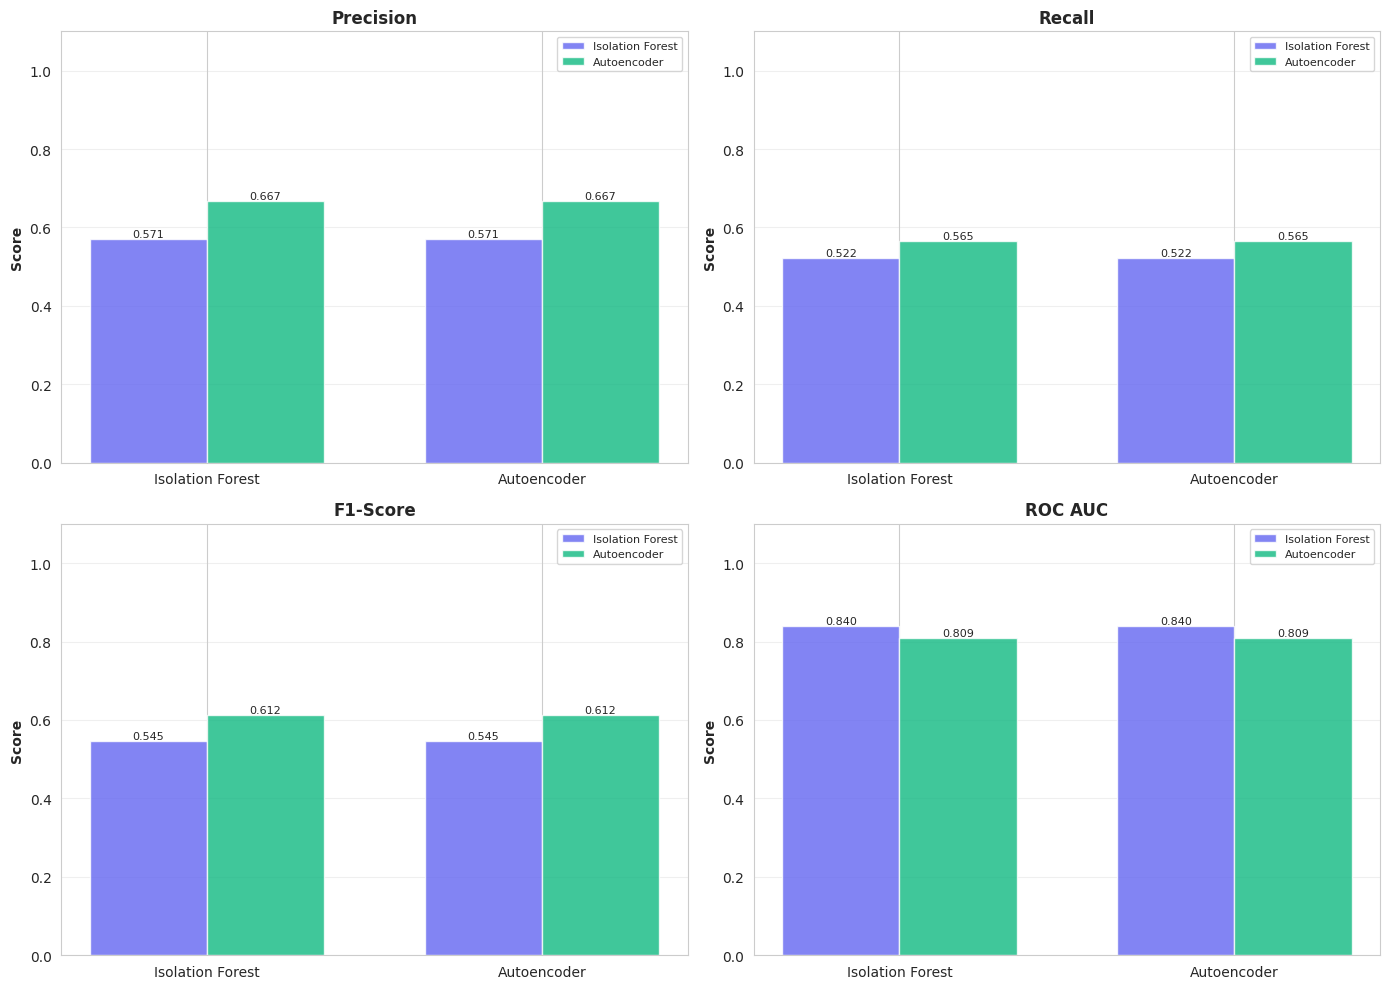


🏆 Best Model (based on F1-Score): Autoencoder
   Isolation Forest F1: 0.5455
   Autoencoder F1: 0.6118


In [48]:
# Compare models
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_if = {
    'Precision': precision_score(y_test, y_pred_if_binary, zero_division=0),
    'Recall': recall_score(y_test, y_pred_if_binary, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_if_binary, zero_division=0),
    'ROC AUC': auc_if if 'auc_if' in locals() else 0.0
}

metrics_ae = {
    'Precision': precision_score(y_test, y_pred_ae_binary, zero_division=0),
    'Recall': recall_score(y_test, y_pred_ae_binary, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ae_binary, zero_division=0),
    'ROC AUC': auc_ae if 'auc_ae' in locals() else 0.0
}

comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Isolation Forest': [metrics_if[m] for m in ['Precision', 'Recall', 'F1-Score', 'ROC AUC']],
    'Autoencoder': [metrics_ae[m] for m in ['Precision', 'Recall', 'F1-Score', 'ROC AUC']]
})

print("\nModel Comparison:")
print(comparison.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_list = ['Precision', 'Recall', 'F1-Score', 'ROC AUC']
for idx, metric in enumerate(metrics_list):
    ax = axes[idx // 2, idx % 2]
    x = np.arange(2)
    width = 0.35
    
    # Create bars with separate labels for each model
    bars1 = ax.bar(x - width/2, metrics_if[metric], width, 
                   label='Isolation Forest', color='#6366f1', alpha=0.8)
    bars2 = ax.bar(x + width/2, metrics_ae[metric], width, 
                   label='Autoencoder', color='#10b981', alpha=0.8)
    
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Isolation Forest', 'Autoencoder'])
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Determine best model
best_model_name = 'Isolation Forest' if metrics_if['F1-Score'] > metrics_ae['F1-Score'] else 'Autoencoder'
print(f"\n🏆 Best Model (based on F1-Score): {best_model_name}")
print(f"   Isolation Forest F1: {metrics_if['F1-Score']:.4f}")
print(f"   Autoencoder F1: {metrics_ae['F1-Score']:.4f}")


## Save Models


In [49]:
import joblib
import json

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save Isolation Forest model and scaler
joblib.dump(isolation_forest, '../models/isolation_forest_anomaly_detector.pkl')
joblib.dump(scaler_if, '../models/if_scaler.pkl')
print("Isolation Forest model and scaler saved")

# Save Autoencoder model
autoencoder.save('../models/autoencoder_anomaly_detector.h5')
joblib.dump(scaler_if, '../models/ae_scaler.pkl')  # Same scaler used
print("Autoencoder model and scaler saved")

# Save threshold for autoencoder
joblib.dump(threshold, '../models/ae_threshold.pkl')
print("Autoencoder threshold saved")

# Save feature columns
with open('../models/anomaly_feature_columns.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print("Feature columns saved")

# Determine best model if not already defined
if 'best_model_name' not in globals():
    best_model_name = 'Isolation Forest' if metrics_if['F1-Score'] > metrics_ae['F1-Score'] else 'Autoencoder'
    print(f"✅ Determined best model: {best_model_name}")

# Save model metadata
model_metadata = {
    'isolation_forest': {
        'precision': float(metrics_if['Precision']),
        'recall': float(metrics_if['Recall']),
        'f1_score': float(metrics_if['F1-Score']),
        'roc_auc': float(metrics_if['ROC AUC'])
    },
    'autoencoder': {
        'precision': float(metrics_ae['Precision']),
        'recall': float(metrics_ae['Recall']),
        'f1_score': float(metrics_ae['F1-Score']),
        'roc_auc': float(metrics_ae['ROC AUC']),
        'threshold': float(threshold)
    },
    'best_model': best_model_name,
    'trained_date': datetime.now().isoformat()
}

with open('../models/anomaly_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("\nModel metadata saved")
print(f"\nTraining completed! Best model: {best_model_name}")


Isolation Forest model and scaler saved
Autoencoder model and scaler saved
Autoencoder threshold saved
Feature columns saved

Model metadata saved

Training completed! Best model: Autoencoder
